# Contour Exploration Workflow

This notebook creates a non-adversarial perturbation as a baseline comparison against adversarial attacks like FGSM, I-FGSM, and PGD.

After relaxation, contour exploration gives us a "control" for comparison by remaining around the same energy

In [1]:
import torch
from pathlib import Path

from ase.md.contour_exploration import ContourExploration
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

from mlff_attack.relaxation import load_structure, setup_calculator, run_relaxation

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

input_cif = Path("../Tl4SnTe3.cif")
outdir = Path("output_contour")
outdir.mkdir(exist_ok=True)

atoms = load_structure(input_cif)

In [3]:
atoms = setup_calculator(
    atoms,
    "uma-s-1p1",
    device=device,
    calculator="uma",
    uma_task="omat",
)

atoms

W0618 17:05:39.851000 28100 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Atoms(symbols='Tl16Sn4Te12', pbc=True, cell=[8.94082, 8.94082, 13.36387], spacegroup_kinds=..., calculator=FAIRChemCalculator(...))

In [4]:
relax_traj_path = outdir / "relaxation.traj"

success = run_relaxation(
    atoms,
    traj_path=relax_traj_path,
    fmax=0.01,
    max_steps=300,
    optimizer="LBFGS",
)

if not success:
    raise RuntimeError("Relaxation failed before contour exploration")

atoms.get_potential_energy()

-98.0503349413247

In [5]:
relaxed_energy = atoms.get_potential_energy()
reference_atoms = atoms.copy()

MaxwellBoltzmannDistribution(atoms, temperature_K=300)

dyn = ContourExploration(
    atoms,
    energy_target=relaxed_energy,
    trajectory=str(outdir / "contour.traj"),
    logfile=str(outdir / "contour.log"),
)

In [6]:
dyn.run(100)

False

In [7]:
atoms.get_potential_energy()

-98.05149115633013

In [8]:
from ase.io import write

write(outdir / "contour_control.cif", atoms)

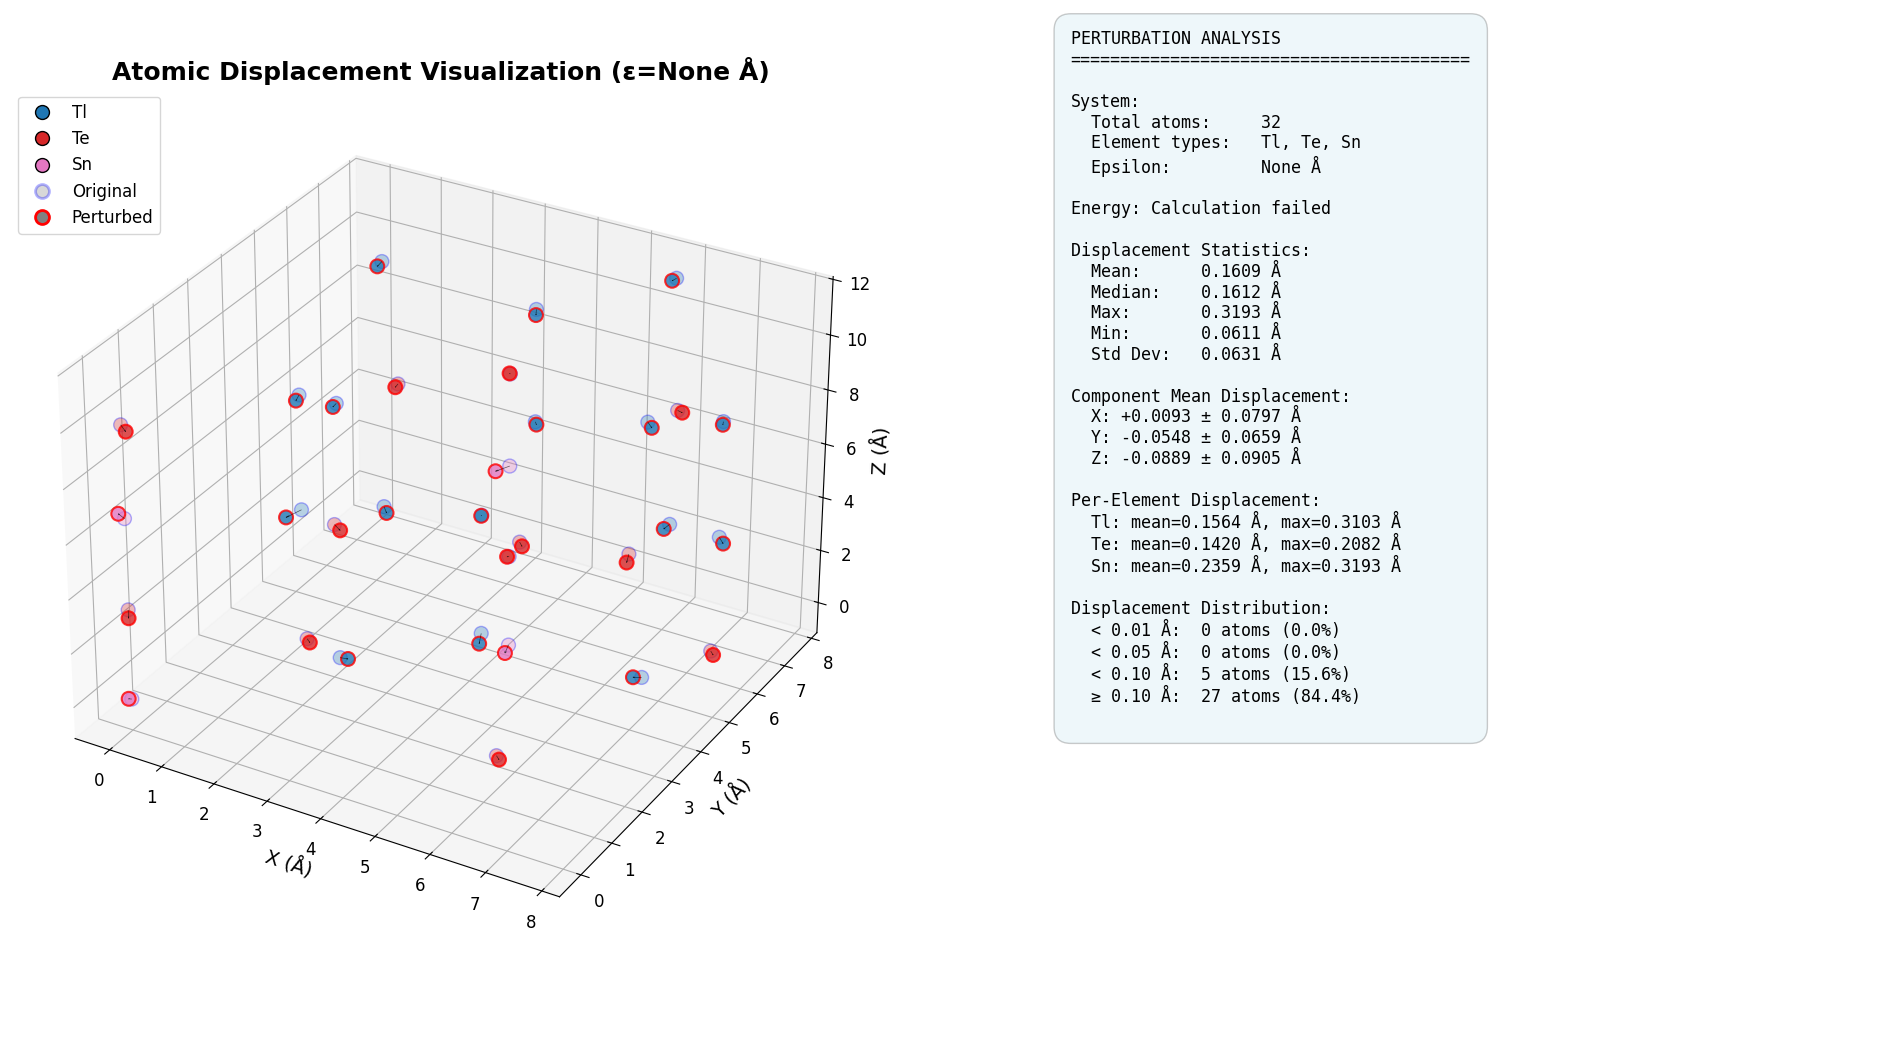

In [9]:
from mlff_attack.attacks import visualize_perturbation

fig = visualize_perturbation(
    reference_atoms,
    atoms,
    epsilon=None,
    outdir=outdir,
)